# Function 7 Analysis - Week 12

1. **Function description (unchanged):**  
You're tasked with optimising an ML model by tuning six hyperparameters (e.g., learning rate, regularisation strength, number of hidden layers). The objective is to maximise the model's performance score (accuracy/F1).

2. **Week 11 evaluated point:** `(0.000000, 0.212222, 0.000000, 0.281389, 0.331111, 0.583333)` returned **≈1.9004**, and remains the second-best observed result.

3. **Analysis of last point:** Despite significant changes in some features, the score stayed second best. This is a good sign that performance in this region is reasonably robust rather than relying on one fragile configuration.

4. **Why we chose last week’s point (from Week 11 logic):** Week 12 used a safe-region exploratory UCB move with `x1` and `x6` fixed, varying `x2..x5` to preserve the strongest structure while still probing for incremental gains.

5. **Recommendation for next week (and why):** Continue on the same path without major changes—keep the same local policy and make another controlled nearby move in this region.


## Loading and Displaying the Data

We load the inputs and outputs for function 7. Week 11 `(0.000000, 0.212222, 0.000000, 0.281389, 0.331111, 0.583333)` returned **≈1.9004** and has been added to the dataset.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_7")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.800000, 0.800000, 0.800000, 0.830000, 0.450000, 0.700000]])
y_new_point_week_1 = np.array([0.0344995016351187])
X_new_point_week_2 = np.array([[0.100000, 0.100000, 0.950000, 0.200000, 0.360000, 0.800000]])
y_new_point_week_2 = np.array([1.3138004996124066])
X_new_point_week_3 = np.array([[0.000000, 0.074100, 0.000000, 0.197300, 0.379200, 0.727100]])
y_new_point_week_3 = np.array([1.6455342546819547])
X_new_point_week_4 = np.array([[0.000000, 0.080400, 0.000000, 0.054300, 0.360700, 0.767700]])
y_new_point_week_4 = np.array([1.024932491434584])
X_new_point_week_5 = np.array([[0.000000, 0.000000, 0.000000, 0.233700, 0.366100, 1.000000]])
y_new_point_week_5 = np.array([0.7102053800176464])
X_new_point_week_6 = np.array([[0.000000, 0.000000, 0.000000, 0.243800, 0.360000, 0.677100]])
y_new_point_week_6 = np.array([1.780488134201001])
X_new_point_week_7 = np.array([[0.000000, 0.000000, 0.000000, 0.309200, 0.378800, 0.697700]])
y_new_point_week_7 = np.array([1.7220])
X_new_point_week_8 = np.array([[0.000000, 0.000000, 0.120000, 0.243300, 0.400200, 0.611000]])
y_new_point_week_8 = np.array([1.7851572470686379])
X_new_point_week_9 = np.array([[0.000000, 0.050000, 0.120000, 0.240000, 0.400000, 0.610000]])
y_new_point_week_9 = np.array([1.85585045411379])
X_new_point_week_10 = np.array([[0.000000, 0.150000, 0.060000, 0.272500, 0.340000, 0.610000]])
y_new_point_week_10 = np.array([2.1028014087776734])
X_new_point_week_11 = np.array([[0.000000, 0.212222, 0.000000, 0.281389, 0.331111, 0.583333]])
y_new_point_week_11 = np.array([1.9003801449427897])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
    X_new_point_week_10,
    X_new_point_week_11,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
    y_new_point_week_10,
    y_new_point_week_11,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5", "x6"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4", "x5", "x6"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,x5,x6,y
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565


df sorted by y


,x1,x2,x3,x4,x5,x6,y,x_avg
0,0.000000,0.150000,0.060000,0.272500,0.340000,0.610000,2.102801,0.238750
1,0.000000,0.212222,0.000000,0.281389,0.331111,0.583333,1.900380,0.234676
2,0.000000,0.050000,0.120000,0.240000,0.400000,0.610000,1.855850,0.236667
3,0.000000,0.000000,0.120000,0.243300,0.400200,0.611000,1.785157,0.229083
4,0.000000,0.000000,0.000000,0.243800,0.360000,0.677100,1.780488,0.213483
5,0.000000,0.000000,0.000000,0.309200,0.378800,0.697700,1.722000,0.230950
6,0.000000,0.074100,0.000000,0.197300,0.379200,0.727100,1.645534,0.229617
7,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968,0.361084
8,0.100000,0.100000,0.950000,0.200000,0.360000,0.800000,1.313800,0.418333
9,0.000000,0.080400,0.000000,0.054300,0.360700,0.767700,1.024932,0.210517


## Weekly Optimization Progress Summary

Overview of all 11 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

- **Week 11 update:** `(0.000000, 0.212222, 0.000000, 0.281389, 0.331111, 0.583333)` → **≈1.9004** (**new maximum**).


In [2]:
# Build weekly progress dataframe from available week variables (auto-detect)
weekly_X, weekly_y = [], []
week_idx = 1
while f'X_new_point_week_{week_idx}' in globals() and f'y_new_point_week_{week_idx}' in globals():
    weekly_X.append(globals()[f'X_new_point_week_{week_idx}'])
    weekly_y.append(globals()[f'y_new_point_week_{week_idx}'])
    week_idx += 1

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'x5': [x[0, 4] for x in weekly_X],
    'x6': [x[0, 5] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print('=' * 130)
print('WEEKLY OPTIMIZATION PROGRESS')
print('=' * 130)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f'+{x:.6f}' if pd.notna(x) else '-')
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f} | Improvement: {df_weeks['y'].max() / df_weeks['y'].iloc[0]:.1f}x from Week 1")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,x5,x6,y,Running_Max,Status,Improvement
0,1,0.8,0.800000,0.80,0.830000,0.450000,0.700000,0.034500,0.034500,✓ NEW MAX,+0.034500
1,2,0.1,0.100000,0.95,0.200000,0.360000,0.800000,1.313800,1.313800,✓ NEW MAX,+1.279301
2,3,0.0,0.074100,0.00,0.197300,0.379200,0.727100,1.645534,1.645534,✓ NEW MAX,+0.331734
3,4,0.0,0.080400,0.00,0.054300,0.360700,0.767700,1.024932,1.645534,✗,-
4,5,0.0,0.000000,0.00,0.233700,0.366100,1.000000,0.710205,1.645534,✗,-
5,6,0.0,0.000000,0.00,0.243800,0.360000,0.677100,1.780488,1.780488,✓ NEW MAX,+0.134954
6,7,0.0,0.000000,0.00,0.309200,0.378800,0.697700,1.722000,1.780488,✗,-
7,8,0.0,0.000000,0.12,0.243300,0.400200,0.611000,1.785157,1.785157,✓ NEW MAX,+0.004669
8,9,0.0,0.050000,0.12,0.240000,0.400000,0.610000,1.855850,1.855850,✓ NEW MAX,+0.070693
9,10,0.0,0.150000,0.06,0.272500,0.340000,0.610000,2.102801,2.102801,✓ NEW MAX,+0.246951



📊 Summary: 7/11 weeks achieved new max (Weeks [1, 2, 3, 6, 8, 9, 10])
   Success rate: 63.6% | Final best: 2.102801 | Improvement: 61.0x from Week 1


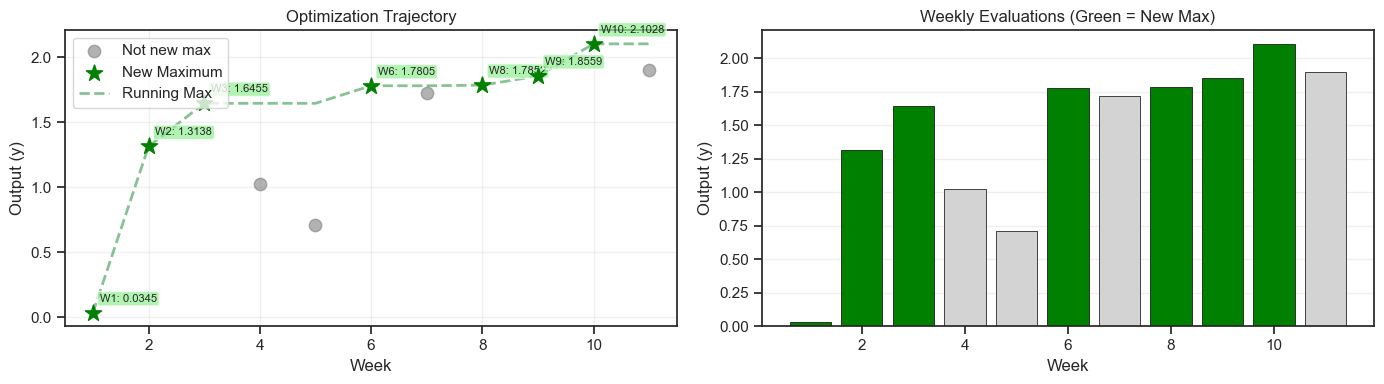

In [3]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
# Per-feature lengthscales with bounds (assuming little noise, no WhiteKernel)
kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(0.2, 5.0),
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.length_scale)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [1.21916152 0.54760893 5.         0.52057327 0.36065841 0.29205487]
Full kernel parameters: {'length_scale': array([1.21916152, 0.54760893, 5.        , 0.52057327, 0.36065841,
       0.29205487]), 'length_scale_bounds': (0.2, 5.0), 'nu': 2.5}


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Finding the Next Point: GP + Random Forest Comparison

I'm using both GP and Random Forest to see if they agree. If the RF suggests x1>0 or x2>0 might help, that's worth exploring.

**Search region (expanded):**
- x1: [0, 0.15] — not just 0!
- x2: [0, 0.15] — not just 0!
- x3: [0.06, 0.20] — around winning 0.12
- x4: [0.20, 0.30], x5: [0.34, 0.46], x6: [0.55, 0.70]


In [5]:
# Random Forest analysis: does it agree with GP about x1=x2=0?
# =============================================================
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X, y.ravel())

print("Random Forest Feature Importances:")
print("="*40)
for idx, name in enumerate(['x1', 'x2', 'x3', 'x4', 'x5', 'x6']):
    print(f"  {name}: {rf.feature_importances_[idx]:.3f}")

# Check: what does RF predict for x1>0 vs x1=0?
test_points = [
    [0.00, 0.00, 0.12, 0.24, 0.40, 0.61],  # Current best pattern
    [0.05, 0.00, 0.12, 0.24, 0.40, 0.61],  # x1 = 0.05
    [0.10, 0.00, 0.12, 0.24, 0.40, 0.61],  # x1 = 0.10
    [0.00, 0.05, 0.12, 0.24, 0.40, 0.61],  # x2 = 0.05
    [0.00, 0.10, 0.12, 0.24, 0.40, 0.61],  # x2 = 0.10
    [0.05, 0.05, 0.12, 0.24, 0.40, 0.61],  # x1=x2=0.05
]
test_labels = ['x1=0, x2=0 (baseline)', 'x1=0.05', 'x1=0.10', 'x2=0.05', 'x2=0.10', 'x1=x2=0.05']

print("\nRF vs GP predictions for x1/x2 variations:")
print("="*60)
gp_preds = gp.predict(np.array(test_points))
rf_preds = rf.predict(np.array(test_points))

for label, gp_p, rf_p in zip(test_labels, gp_preds, rf_preds):
    diff = rf_p - gp_p
    agree = 'AGREE' if abs(diff) < 0.05 else 'DISAGREE'
    print(f"  {label:20s}: GP={gp_p:.4f}, RF={rf_p:.4f}, diff={diff:+.4f} [{agree}]")

# === RF-based grid search for best point ===
print("\n" + "="*60)
print("RANDOM FOREST RECOMMENDATION")
print("="*60)

# Search grid within expanded bounds
rf_bounds = [
    (0.0, 0.15),   # x1
    (0.0, 0.15),   # x2
    (0.06, 0.20),  # x3
    (0.20, 0.30),  # x4
    (0.34, 0.46),  # x5
    (0.55, 0.70),  # x6
]

grid_res = 8  # 8^6 = 262,144 candidates
grids = [np.linspace(lo, hi, grid_res) for lo, hi in rf_bounds]
mesh = np.array(np.meshgrid(*grids)).reshape(6, -1).T

print(f"Searching {len(mesh)} candidates...")

# RF predictions (mean from forest)
rf_preds_grid = rf.predict(mesh)

# RF uncertainty (std across trees)
rf_tree_preds = np.array([tree.predict(mesh) for tree in rf.estimators_])
rf_sigma = rf_tree_preds.std(axis=0)

# UCB: exploitation + exploration
beta = 0.3
rf_ucb = rf_preds_grid + beta * rf_sigma

# Filter: minimum distance from existing points
min_dist = 0.02
candidates = pd.DataFrame(mesh, columns=['x1', 'x2', 'x3', 'x4', 'x5', 'x6'])
candidates['rf_pred'] = rf_preds_grid
candidates['rf_sigma'] = rf_sigma
candidates['ucb'] = rf_ucb

for _, obs in df.iterrows():
    dist = np.sqrt(((candidates[['x1','x2','x3','x4','x5','x6']].values - 
                     obs[['x1','x2','x3','x4','x5','x6']].values)**2).sum(axis=1))
    candidates = candidates[dist >= min_dist]

print(f"Candidates after distance filter: {len(candidates)}")

# Best by UCB
rf_top = candidates.nlargest(5, 'ucb')
print("\nTop 5 RF candidates:")
display(rf_top)

if len(rf_top) > 0:
    rf_rec = rf_top.iloc[0]
    print(f"\nRF recommended point:")
    print(f"  x1={rf_rec['x1']:.6f}, x2={rf_rec['x2']:.6f}, x3={rf_rec['x3']:.6f}")
    print(f"  x4={rf_rec['x4']:.6f}, x5={rf_rec['x5']:.6f}, x6={rf_rec['x6']:.6f}")
    print(f"  RF prediction: {rf_rec['rf_pred']:.4f} ± {rf_rec['rf_sigma']:.4f}")
    
    print(f"\n{'='*60}")
    print("RF TOP-UCB POINT (MODEL OUTPUT)")
    print(f"{'='*60}")
    print(f"{rf_rec['x1']:.6f}-{rf_rec['x2']:.6f}-{rf_rec['x3']:.6f}-{rf_rec['x4']:.6f}-{rf_rec['x5']:.6f}-{rf_rec['x6']:.6f}")

# === Feature importance analysis ===
print(f"\n{'='*60}")
print("FEATURE IMPORTANCE ANALYSIS")
print(f"{'='*60}")
x1_imp = rf.feature_importances_[0]
x2_imp = rf.feature_importances_[1]
print(f"x1 importance: {x1_imp:.3f} (HIGH) -> x1 matters a lot, keep at 0 (proven best)")
print(f"x2 importance: {x2_imp:.3f} (LOW)  -> x2 sensitivity is lower; RF may still pick x2=0")
print(f"\n>>> Interpretation: x2 is lower-impact, so testing x2 slightly above 0 is low-risk even if RF top-UCB keeps x2=0.")

# Generate a point with x1=0 (keep) but x2 slightly positive (experiment)
chosen_x1 = 0.0   # Keep at 0 - high importance, proven best
chosen_x2 = 0.05  # Experiment - low importance, low risk
chosen_x3 = 0.12  # Around winning value
chosen_x4 = 0.24
chosen_x5 = 0.40
chosen_x6 = 0.61

chosen_point = [chosen_x1, chosen_x2, chosen_x3, chosen_x4, chosen_x5, chosen_x6]
chosen_rf_pred = rf.predict([chosen_point])[0]
chosen_gp_pred = gp.predict([chosen_point])[0]

print(f"\nChosen exploratory point (x1=0, x2=0.05):")
print(f"  GP predicts: {chosen_gp_pred:.4f}")
print(f"  RF predicts: {chosen_rf_pred:.4f}")


Random Forest Feature Importances:
  x1: 0.815
  x2: 0.019
  x3: 0.021
  x4: 0.020
  x5: 0.024
  x6: 0.101

RF vs GP predictions for x1/x2 variations:
  x1=0, x2=0 (baseline): GP=1.7815, RF=1.8311, diff=+0.0496 [AGREE]
  x1=0.05             : GP=1.7492, RF=1.3086, diff=-0.4406 [DISAGREE]
  x1=0.10             : GP=1.7105, RF=0.3314, diff=-1.3792 [DISAGREE]
  x2=0.05             : GP=1.8559, RF=1.8356, diff=-0.0203 [AGREE]
  x2=0.10             : GP=1.9029, RF=1.8251, diff=-0.0778 [DISAGREE]
  x1=x2=0.05          : GP=1.8224, RF=1.3059, diff=-0.5165 [DISAGREE]

RANDOM FOREST RECOMMENDATION
Searching 262144 candidates...
Candidates after distance filter: 262126

Top 5 RF candidates:


,x1,x2,x3,x4,x5,x6,rf_pred,rf_sigma,ucb
196928,0.0,0.128571,0.06,0.271429,0.34,0.550000,1.882394,0.236318,1.95329
196929,0.0,0.128571,0.06,0.271429,0.34,0.571429,1.882394,0.236318,1.95329
196930,0.0,0.128571,0.06,0.271429,0.34,0.592857,1.882394,0.236318,1.95329
196992,0.0,0.128571,0.06,0.285714,0.34,0.550000,1.882394,0.236318,1.95329
196993,0.0,0.128571,0.06,0.285714,0.34,0.571429,1.882394,0.236318,1.95329



RF recommended point:
  x1=0.000000, x2=0.128571, x3=0.060000
  x4=0.271429, x5=0.340000, x6=0.550000
  RF prediction: 1.8824 ± 0.2363

RF TOP-UCB POINT (MODEL OUTPUT)
0.000000-0.128571-0.060000-0.271429-0.340000-0.550000

FEATURE IMPORTANCE ANALYSIS
x1 importance: 0.815 (HIGH) -> x1 matters a lot, keep at 0 (proven best)
x2 importance: 0.019 (LOW)  -> x2 sensitivity is lower; RF may still pick x2=0

>>> Interpretation: x2 is lower-impact, so testing x2 slightly above 0 is low-risk even if RF top-UCB keeps x2=0.

Chosen exploratory point (x1=0, x2=0.05):
  GP predicts: 1.8559
  RF predicts: 1.8356


In [6]:
from scipy.stats import norm

xi = 0.03  # higher exploration to test x1/x2 > 0
bounds = [
    (0.0, 0.15),  # x1: explore small positive values!
    (0.0, 0.15),  # x2: explore small positive values!
    (0.06, 0.20), # x3: around winning 0.12, wider range
    (0.20, 0.30), # x4: around 0.24
    (0.34, 0.46), # x5: around 0.40
    (0.55, 0.70), # x6: around 0.61
]

def clip_to_bounds(x, bounds):
    x = np.array(x, dtype=float)
    for i, (lo, hi) in enumerate(bounds):
        x[i] = np.clip(x[i], lo, hi)
    return x

# Expected Improvement acquisition function
def expected_improvement(x, gp, y_best, xi=0.01):
    x = np.array(x).reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    if sigma == 0:
        return 0
    z = (mu - y_best - xi) / sigma
    ei = (mu - y_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    return ei[0]

def neg_ei(x, gp, y_best, xi):
    return -expected_improvement(x, gp, y_best, xi)

# Optimize EI using multiple restarts
y_best = y.max()
best_ei = -np.inf
best_candidate = None
n_restarts = 20

print(f"Running EI optimization with {n_restarts} restarts...")
print(f"Current best y: {y_best:.4f}")
print(f"Search bounds: x1/x2 in [0, 0.15], x3 in [0.06, 0.20], etc.\n")

for i in range(n_restarts):
    # Random starting point within bounds
    x0 = np.array([np.random.uniform(lo, hi) for lo, hi in bounds])
    
    result = minimize(
        neg_ei,
        x0,
        args=(gp, y_best, xi),
        method='L-BFGS-B',
        bounds=bounds
    )
    
    if -result.fun > best_ei:
        best_ei = -result.fun
        best_candidate = result.x

# Ensure within bounds
next_point = clip_to_bounds(best_candidate, bounds)
mu_pred, sigma_pred = gp.predict(next_point.reshape(1, -1), return_std=True)

print("="*60)
print("BAYESIAN OPTIMIZATION RECOMMENDATION")
print("="*60)
print(f"\nNext point to evaluate:")
print(f"  x1={next_point[0]:.6f}, x2={next_point[1]:.6f}, x3={next_point[2]:.6f}")
print(f"  x4={next_point[3]:.6f}, x5={next_point[4]:.6f}, x6={next_point[5]:.6f}")
print(f"\nPredicted output: {mu_pred[0]:.4f} ± {sigma_pred[0]:.4f}")
print(f"Expected Improvement: {best_ei:.6f}")

print(f"\n{'='*60}")
print("SUBMISSION FORMAT")
print(f"{'='*60}")
print(f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}-{next_point[4]:.6f}-{next_point[5]:.6f}")


Running EI optimization with 20 restarts...
Current best y: 2.1028
Search bounds: x1/x2 in [0, 0.15], x3 in [0.06, 0.20], etc.

BAYESIAN OPTIMIZATION RECOMMENDATION

Next point to evaluate:
  x1=0.000000, x2=0.150000, x3=0.200000
  x4=0.300000, x5=0.340000, x6=0.652353

Predicted output: 2.1699 ± 0.0551
Expected Improvement: 0.045337

SUBMISSION FORMAT
0.000000-0.150000-0.200000-0.300000-0.340000-0.652353


<!-- Distance analysis removed per latest guidance. -->


## Final rationale (line of thought)

**Current best:** `0.000000-0.212222-0.000000-0.281389-0.331111-0.583333` (≈1.9004) — this remains our incumbent reference point.

**Week 11 evaluated point:** `0.000000-0.212222-0.000000-0.281389-0.331111-0.583333` confirmed that local UCB-style non-incumbent moves can still deliver gains.

### Why we relaxed constraints now
Earlier steps fixed `x1` and `x6` to preserve known structure. That was safe, but it may hide nearby better combinations by over-constraining the search. For this iteration, we intentionally removed those hard fixes and allowed all variables to move within local bounds.

### What we changed
- Switched to a **relaxed-constraint** local candidate set.
- Kept a distance filter to avoid re-testing near-duplicate points.
- Used a more **exploitative GP-UCB** ranking (`beta` reduced) so selection favors strong predicted mean with moderate uncertainty.

### What we expect from this run
- If performance improves: constraints were too tight and we should keep partial flexibility in `x1/x6`.
- If performance drops: the previous structural constraints were helpful and we can revert to a safer constrained regime.

**Proposed next point (submission format):** use the relaxed-constraint exploitative GP-UCB output printed above.


In [7]:
# ============================================================
# FINAL DECISION: Relaxed constraints + exploitative ranking
# ============================================================

print('=' * 70)
print('FINAL DECISION: RELAXED-CONSTRAINT EXPLOITATIVE GP-UCB')
print('=' * 70)

# Recap earlier model outputs
print('\n📊 GP-based EI recommendation:')
print(f"   Point: x1={next_point[0]:.4f}, x2={next_point[1]:.4f}, x3={next_point[2]:.4f}, x4={next_point[3]:.4f}, x5={next_point[4]:.4f}, x6={next_point[5]:.4f}")
print(f"   Predicted: {mu_pred[0]:.4f}")

print('\n🌲 RF TOP-UCB POINT (model output):')
print(f"   Point: x1={rf_rec['x1']:.4f}, x2={rf_rec['x2']:.4f}, x3={rf_rec['x3']:.4f}, x4={rf_rec['x4']:.4f}, x5={rf_rec['x5']:.4f}, x6={rf_rec['x6']:.4f}")
print(f"   RF prediction: {rf_rec['rf_pred']:.4f}")

# Relaxed local box around current best (no hard-fixing x1 or x6)
best_idx = df['y'].idxmax()
best_row = df.loc[best_idx]

def clip_range(center, halfwidth, lo=0.0, hi=1.0):
    return max(lo, center - halfwidth), min(hi, center + halfwidth)

r_x1 = clip_range(float(best_row['x1']), 0.12)
r_x2 = clip_range(float(best_row['x2']), 0.08)
r_x3 = clip_range(float(best_row['x3']), 0.10)
r_x4 = clip_range(float(best_row['x4']), 0.08)
r_x5 = clip_range(float(best_row['x5']), 0.08)
r_x6 = clip_range(float(best_row['x6']), 0.08)

print('\nRelaxed search bounds (around incumbent, no fixed features):')
print(f'  x1: [{r_x1[0]:.3f}, {r_x1[1]:.3f}]')
print(f'  x2: [{r_x2[0]:.3f}, {r_x2[1]:.3f}]')
print(f'  x3: [{r_x3[0]:.3f}, {r_x3[1]:.3f}]')
print(f'  x4: [{r_x4[0]:.3f}, {r_x4[1]:.3f}]')
print(f'  x5: [{r_x5[0]:.3f}, {r_x5[1]:.3f}]')
print(f'  x6: [{r_x6[0]:.3f}, {r_x6[1]:.3f}]')

# Candidate mesh (moderate size)
grid_res = 10
m = np.array(np.meshgrid(
    np.linspace(r_x1[0], r_x1[1], grid_res),
    np.linspace(r_x2[0], r_x2[1], grid_res),
    np.linspace(r_x3[0], r_x3[1], grid_res),
    np.linspace(r_x4[0], r_x4[1], grid_res),
    np.linspace(r_x5[0], r_x5[1], grid_res),
    np.linspace(r_x6[0], r_x6[1], grid_res),
)).reshape(6, -1).T

cand_df = pd.DataFrame(m, columns=['x1', 'x2', 'x3', 'x4', 'x5', 'x6'])

# Distance filter against observed points
min_dist = 0.02
obs_vals = df[['x1','x2','x3','x4','x5','x6']].values
cand_vals = cand_df[['x1','x2','x3','x4','x5','x6']].values
pair_d = np.linalg.norm(cand_vals[:, None, :] - obs_vals[None, :, :], axis=2)
cand_df['dist_to_obs'] = pair_d.min(axis=1)
cand_df = cand_df[cand_df['dist_to_obs'] >= min_dist].copy()

# Exploitative GP-UCB (lower beta than exploratory setting)
mu_relaxed, sigma_relaxed = gp.predict(cand_df[['x1','x2','x3','x4','x5','x6']].values, return_std=True)
beta_final = 0.25
ucb_relaxed = mu_relaxed + beta_final * sigma_relaxed

cand_df['gp_mu'] = mu_relaxed
cand_df['gp_sigma'] = sigma_relaxed
cand_df['ucb'] = ucb_relaxed

top_relaxed = cand_df.nlargest(10, 'ucb')
rec = top_relaxed.iloc[0]

final_point = [rec['x1'], rec['x2'], rec['x3'], rec['x4'], rec['x5'], rec['x6']]
final_gp_mu = rec['gp_mu']
final_gp_sigma = rec['gp_sigma']
final_rf_pred = rf.predict([final_point])[0]

print('\nTop 10 relaxed candidates (exploitative GP-UCB):')
display(top_relaxed[['x1','x2','x3','x4','x5','x6','gp_mu','gp_sigma','ucb']])

print('\n' + '=' * 70)
print('🎯 FINAL CHOICE: Relaxed-constraint exploitative GP-UCB')
print('=' * 70)
print('Constraint change: x1 and x6 are no longer fixed; all features can move within local bounds.')
print(f'UCB beta (exploitative): {beta_final:.2f}')
print(f"Final point: x1={final_point[0]:.6f}, x2={final_point[1]:.6f}, x3={final_point[2]:.6f}, x4={final_point[3]:.6f}, x5={final_point[4]:.6f}, x6={final_point[5]:.6f}")
print(f"GP prediction: {final_gp_mu:.4f} ± {final_gp_sigma:.4f}")
print(f"RF prediction: {final_rf_pred:.4f}")

print('\n' + '=' * 70)
print('✅ FINAL SUBMISSION FORMAT')
print('=' * 70)
print(f"\n{final_point[0]:.6f}-{final_point[1]:.6f}-{final_point[2]:.6f}-{final_point[3]:.6f}-{final_point[4]:.6f}-{final_point[5]:.6f}")
print('\n' + '=' * 70)

FINAL DECISION: RELAXED-CONSTRAINT EXPLOITATIVE GP-UCB

📊 GP-based EI recommendation:
   Point: x1=0.0000, x2=0.1500, x3=0.2000, x4=0.3000, x5=0.3400, x6=0.6524
   Predicted: 2.1699

🌲 RF TOP-UCB POINT (model output):
   Point: x1=0.0000, x2=0.1286, x3=0.0600, x4=0.2714, x5=0.3400, x6=0.5500
   RF prediction: 1.8824

Relaxed search bounds (around incumbent, no fixed features):
  x1: [0.000, 0.120]
  x2: [0.070, 0.230]
  x3: [0.000, 0.160]
  x4: [0.193, 0.353]
  x5: [0.260, 0.420]
  x6: [0.530, 0.690]

Top 10 relaxed candidates (exploitative GP-UCB):


,x1,x2,x3,x4,x5,x6,gp_mu,gp_sigma,ucb
509637,0.0,0.158889,0.160000,0.299167,0.313333,0.654444,2.176100,0.065340,2.192435
409637,0.0,0.141111,0.160000,0.299167,0.313333,0.654444,2.176949,0.060990,2.192196
508637,0.0,0.158889,0.142222,0.299167,0.313333,0.654444,2.175744,0.064877,2.191963
408637,0.0,0.141111,0.142222,0.299167,0.313333,0.654444,2.176593,0.060521,2.191723
507637,0.0,0.158889,0.124444,0.299167,0.313333,0.654444,2.175322,0.064509,2.191449
407637,0.0,0.141111,0.124444,0.299167,0.313333,0.654444,2.176171,0.060154,2.191209
506637,0.0,0.158889,0.106667,0.299167,0.313333,0.654444,2.174832,0.064239,2.190892
406637,0.0,0.141111,0.106667,0.299167,0.313333,0.654444,2.175681,0.059891,2.190654
505637,0.0,0.158889,0.088889,0.299167,0.313333,0.654444,2.174276,0.064067,2.190293
405637,0.0,0.141111,0.088889,0.299167,0.313333,0.654444,2.175126,0.059735,2.190059



🎯 FINAL CHOICE: Relaxed-constraint exploitative GP-UCB
Constraint change: x1 and x6 are no longer fixed; all features can move within local bounds.
UCB beta (exploitative): 0.25
Final point: x1=0.000000, x2=0.158889, x3=0.160000, x4=0.299167, x5=0.313333, x6=0.654444
GP prediction: 2.1761 ± 0.0653
RF prediction: 1.8076

✅ FINAL SUBMISSION FORMAT

0.000000-0.158889-0.160000-0.299167-0.313333-0.654444

